In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [3]:
df = pd.read_csv("dataset.csv")

In [4]:
df

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D
...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,Male,2.8,75.4,8.2,Masters,Yes,Yes,No,60.5,70.7,C
996,997,Male,6.7,88.4,7.1,NaN,No,Yes,No,82.2,99.5,A
997,998,Female,2.6,84.5,8.0,High School,Yes,Yes,Yes,65.2,79.2,C
998,999,Female,4.6,85.3,8.1,High School,No,No,Yes,52.2,82.2,B


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   str    
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    str    
 6   internet_access             1000 non-null   str    
 7   extracurricular_activities  1000 non-null   str    
 8   part_time_job               1000 non-null   str    
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   str    
dtypes: float64(5), int64(1), str(6)
memory usage: 93.9 KB


In [6]:
df.isna().sum()

student_id                      0
gender                          0
study_time_hours                0
attendance_percent              0
sleep_hours                     0
parental_education            102
internet_access                 0
extracurricular_activities      0
part_time_job                   0
previous_grade                  0
final_exam_score                0
final_grade                     0
dtype: int64

In [7]:
df = df.fillna('NOT Available')

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,student_id,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,3.570700,85.092300,6.799500,69.740900,83.543500
std,288.819436,1.478559,9.270685,1.203527,12.613425,10.341333
min,1.000000,0.500000,54.800000,3.200000,31.300000,46.800000
25%,250.750000,2.600000,78.800000,5.900000,61.000000,76.075000
50%,500.500000,3.600000,85.200000,6.800000,69.600000,83.800000
75%,750.250000,4.500000,91.900000,7.600000,78.400000,91.525000
max,1000.000000,8.100000,100.000000,10.000000,100.000000,100.000000


In [10]:
df = df.drop(columns=['student_id'])

In [11]:
# copy so you can recover if needed
df_clean = df.copy()

# choose numeric columns only
num_cols = df_clean.select_dtypes(include='number').columns.tolist()

# compute IQR bounds per column and remove rows that are outliers in any numeric column
def remove_outliers_iqr(df, cols, k=1.5):
    mask = pd.Series(False, index=df.index)  # True = row is an outlier (to drop)
    for c in cols:
        q1 = df[c].quantile(0.25)
        q3 = df[c].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - k * iqr
        upper = q3 + k * iqr
        mask = mask | (df[c] < lower) | (df[c] > upper)
    return df.loc[~mask].reset_index(drop=True), mask.sum()

df_no_outliers, n_dropped = remove_outliers_iqr(df_clean, num_cols, k=1.5)
print(f"Removed {n_dropped}" )

Removed 16


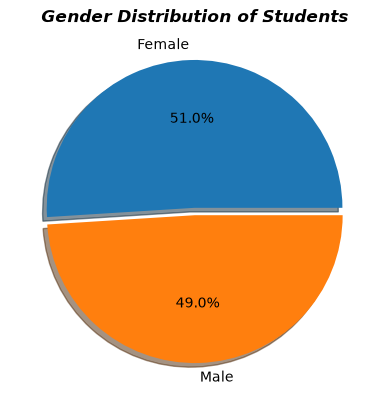

In [12]:
gender = df['gender'].value_counts()

explode = [0.05,0]
gender.plot(kind='pie',autopct='%1.1f%%',explode=explode,shadow=True)

plt.ylabel('')
plt.title('Gender Distribution of Students',fontweight='bold',style='italic')
plt.show()

In [13]:
df

,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,Male,2.6,77.5,8.0,NOT Available,Yes,Yes,No,85.1,83.8,B
4,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D
...,...,...,...,...,...,...,...,...,...,...,...
995,Male,2.8,75.4,8.2,Masters,Yes,Yes,No,60.5,70.7,C
996,Male,6.7,88.4,7.1,NOT Available,No,Yes,No,82.2,99.5,A
997,Female,2.6,84.5,8.0,High School,Yes,Yes,Yes,65.2,79.2,C
998,Female,4.6,85.3,8.1,High School,No,No,Yes,52.2,82.2,B


In [14]:
study_score = (
    df.groupby('study_time_hours', as_index=False)['final_exam_score']
      .mean()
      .sort_values('study_time_hours')
)
study_score

,study_time_hours,final_exam_score
0,0.5,71.026087
1,0.7,71.825000
2,0.8,75.633333
3,0.9,71.433333
4,1.0,75.587500
...,...,...
65,7.1,100.000000
66,7.2,97.475000
67,7.3,93.900000
68,7.4,99.133333


In [15]:
score_correlation = df['study_time_hours'].corr(df['final_exam_score'])
score_correlation

np.float64(0.5675131881039118)

In [16]:
df

,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,Male,2.6,77.5,8.0,NOT Available,Yes,Yes,No,85.1,83.8,B
4,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D
...,...,...,...,...,...,...,...,...,...,...,...
995,Male,2.8,75.4,8.2,Masters,Yes,Yes,No,60.5,70.7,C
996,Male,6.7,88.4,7.1,NOT Available,No,Yes,No,82.2,99.5,A
997,Female,2.6,84.5,8.0,High School,Yes,Yes,Yes,65.2,79.2,C
998,Female,4.6,85.3,8.1,High School,No,No,Yes,52.2,82.2,B


In [17]:
male = df[df['gender']=='Male']['final_grade'].value_counts().sort_index(ascending=True)
male

final_grade
A    144
B    168
C    127
D     45
F      6
Name: count, dtype: int64

In [18]:
female = df[df['gender']=='Female']['final_grade'].value_counts()
female

final_grade
B    186
A    140
C    134
D     44
F      6
Name: count, dtype: int64

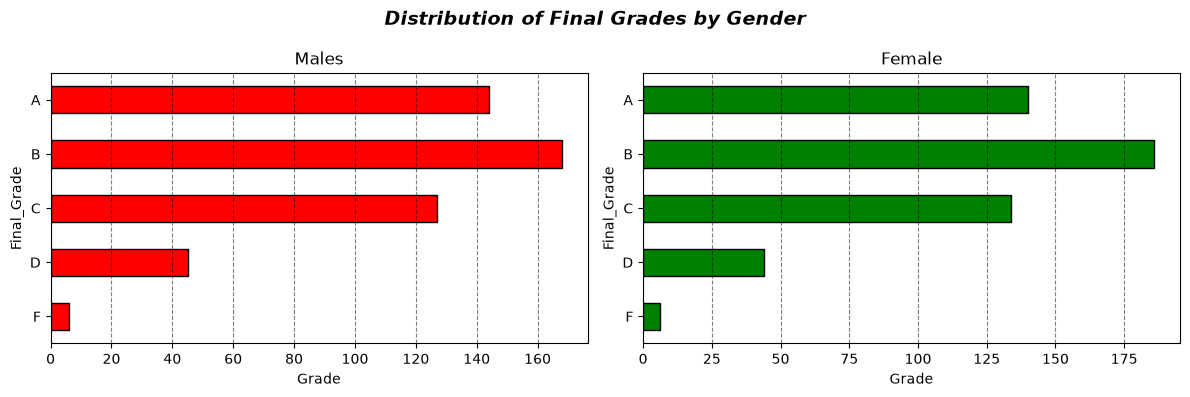

In [19]:
fig,axes = plt.subplots(1,2,figsize=(12,4))

male.sort_index(ascending=False).plot(kind='barh',
                                      ax=axes[0],
                                      color='red',
                                      edgecolor='black')


axes[0].set_title("Males")
axes[0].set_xlabel("Grade")
axes[0].set_ylabel("Final_Grade")

axes[0].grid(axis='x',linestyle='--',color='black',alpha=0.5)



female.sort_index(ascending=False).plot(kind='barh',
                                        ax=axes[1],
                                        color='green',
                                        edgecolor='black')

axes[1].set_title("Female")
axes[1].set_xlabel("Grade")
axes[1].set_ylabel("Final_Grade")

axes[1].grid(axis='x',
             linestyle='--',
            color='black',
            alpha=0.5)


fig.suptitle("Distribution of Final Grades by Gender", fontsize=14,fontweight='bold',style='italic')
plt.tight_layout()
plt.subplots_adjust(top=0.88)  


plt.tight_layout()
plt.show()

In [20]:
# how many student have the part time jab and got the grade A 
part_time_job_NO = df[df['part_time_job'] == 'No']['final_grade'].value_counts()
part_time_job_NO

final_grade
B    245
A    213
C    180
D     41
F      5
Name: count, dtype: int64

In [21]:
part_time_job_YES = df[df['part_time_job'] == 'Yes']['final_grade'].value_counts()
part_time_job_YES

final_grade
B    109
C     81
A     71
D     48
F      7
Name: count, dtype: int64

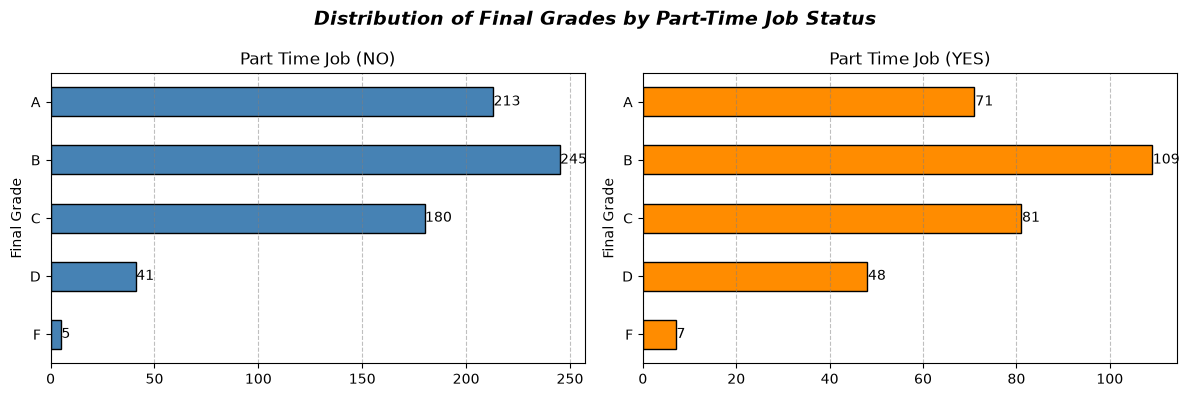

In [22]:
fig,axes = plt.subplots(1,2,figsize=(12,4))

part_time_job_NO.sort_index(ascending=False).plot(kind='barh',
                                      ax=axes[0],
                                      color='steelblue',
                                      edgecolor='black')

for i, value in enumerate(part_time_job_NO.sort_index(ascending=False).values):
    axes[0].text(value + 0.2, i, str(value), va='center')

axes[0].set_title("Part Time Job (NO)")
axes[0].set_xlabel("")
axes[0].set_ylabel("Final Grade")

axes[0].grid(axis='x',linestyle='--',color='gray',alpha=0.5)



part_time_job_YES.sort_index(ascending=False).plot(kind='barh',
                                        ax=axes[1],
                                        color='darkorange',
                                        edgecolor='black')

for i, value in enumerate(part_time_job_YES.sort_index(ascending=False).values):
    axes[1].text(value + 0.2, i, str(value), va='center')

axes[1].set_title("Part Time Job (YES)")
axes[1].set_xlabel("")
axes[1].set_ylabel("Final Grade")

axes[1].grid(axis='x',
             linestyle='--',
            color='gray',
            alpha=0.5)


fig.suptitle("Distribution of Final Grades by Part-Time Job Status", fontsize=14, fontweight='bold', style='italic')
plt.tight_layout()
plt.subplots_adjust(top=0.88)  


plt.tight_layout()
plt.show()

In [23]:
df

,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,Male,2.6,77.5,8.0,NOT Available,Yes,Yes,No,85.1,83.8,B
4,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D
...,...,...,...,...,...,...,...,...,...,...,...
995,Male,2.8,75.4,8.2,Masters,Yes,Yes,No,60.5,70.7,C
996,Male,6.7,88.4,7.1,NOT Available,No,Yes,No,82.2,99.5,A
997,Female,2.6,84.5,8.0,High School,Yes,Yes,Yes,65.2,79.2,C
998,Female,4.6,85.3,8.1,High School,No,No,Yes,52.2,82.2,B


In [24]:
attendance_score = (
    df.groupby('attendance_percent', as_index=False)['final_exam_score']
      .mean()
      .sort_values('final_exam_score',ascending=False).reset_index(drop=True)
)
attendance_score

,attendance_percent,final_exam_score
0,67.5,100.0
1,71.3,100.0
2,99.0,100.0
3,98.6,100.0
4,71.9,99.9
...,...,...
322,63.6,63.3
323,55.8,61.1
324,62.9,60.8
325,75.8,59.4


In [25]:
attendance_correlation = df['attendance_percent'].corr(df['final_exam_score'])
attendance_correlation

np.float64(0.26187177909198595)

In [26]:
df

,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,Male,2.6,77.5,8.0,NOT Available,Yes,Yes,No,85.1,83.8,B
4,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D
...,...,...,...,...,...,...,...,...,...,...,...
995,Male,2.8,75.4,8.2,Masters,Yes,Yes,No,60.5,70.7,C
996,Male,6.7,88.4,7.1,NOT Available,No,Yes,No,82.2,99.5,A
997,Female,2.6,84.5,8.0,High School,Yes,Yes,Yes,65.2,79.2,C
998,Female,4.6,85.3,8.1,High School,No,No,Yes,52.2,82.2,B


In [27]:
extracurricular_activities_NO = df[df['extracurricular_activities'] == 'No']['final_grade'].value_counts()
extracurricular_activities_NO

final_grade
B    156
C    119
A    113
D     37
F      3
Name: count, dtype: int64

In [28]:
extracurricular_activities_Yes = df[df['extracurricular_activities'] == 'Yes']['final_grade'].value_counts()
extracurricular_activities_Yes

final_grade
B    198
A    171
C    142
D     52
F      9
Name: count, dtype: int64

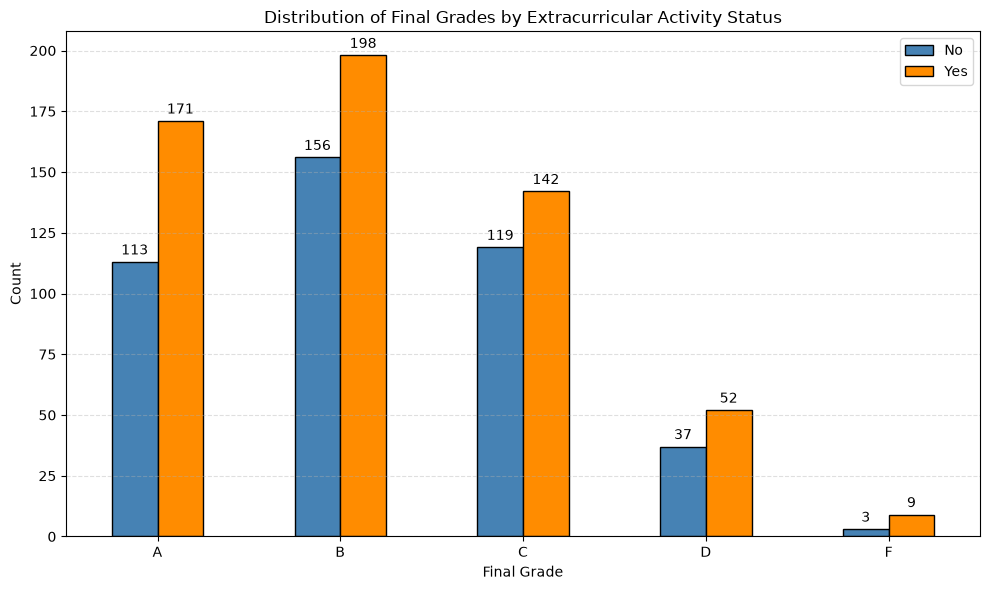

In [29]:
import matplotlib.pyplot as plt
import pandas as pd

extracurricular_no = df[df['extracurricular_activities'] == 'No']['final_grade'].value_counts()
extracurricular_yes = df[df['extracurricular_activities'] == 'Yes']['final_grade'].value_counts()

chart_df = pd.DataFrame({
    'No': extracurricular_no,
    'Yes': extracurricular_yes
}).fillna(0).sort_index()

ax = chart_df.plot(kind='bar', figsize=(10, 6), color=['steelblue', 'darkorange'], edgecolor='black')

for container in ax.containers:
    ax.bar_label(container, padding=3)

ax.set_title("Distribution of Final Grades by Extracurricular Activity Status")
ax.set_xlabel("Final Grade")
ax.set_ylabel("Count")
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [30]:
previous_grade_score = (
    df.groupby('previous_grade', as_index=False)['final_exam_score']
      .mean()
      .sort_values('final_exam_score',ascending=False).reset_index(drop=True)
)
previous_grade_score

,previous_grade,final_exam_score
0,93.3,100.0
1,92.8,100.0
2,93.0,100.0
3,92.5,100.0
4,92.0,100.0
...,...,...
429,56.1,61.8
430,76.1,61.1
431,36.7,60.0
432,45.0,57.3


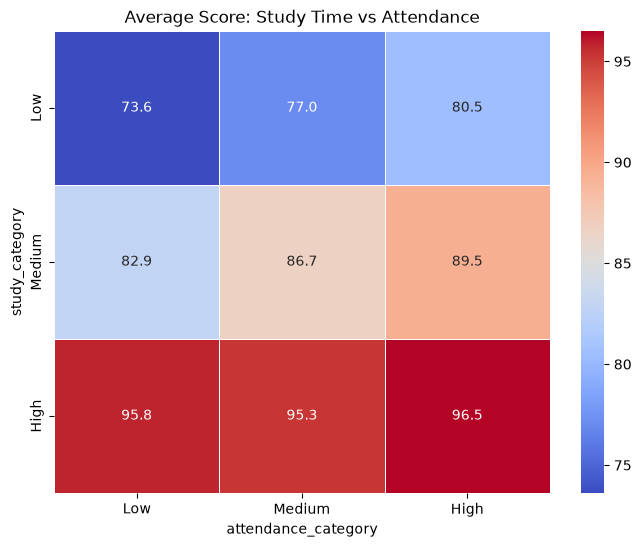

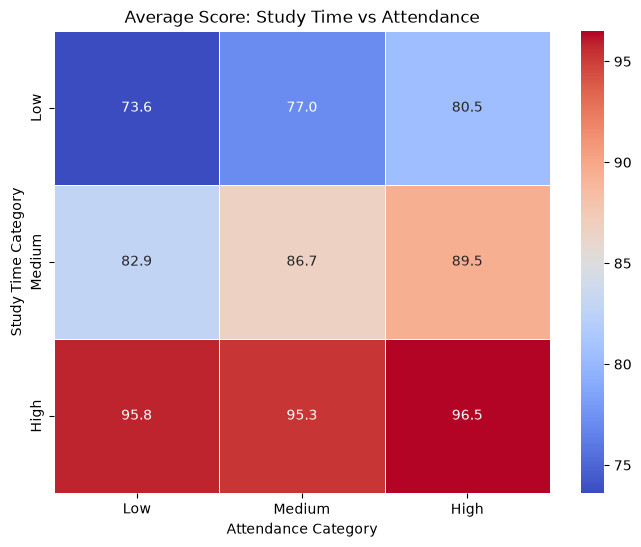

In [31]:
# STEP 1: Create the categories first (THIS IS WHAT YOU'RE MISSING)
df['study_category'] = pd.cut(df['study_time_hours'], 
                               bins=[0, 3, 6, 10], 
                               labels=['Low', 'Medium', 'High'])

df['attendance_category'] = pd.cut(df['attendance_percent'], 
                                    bins=[0, 80, 90, 100], 
                                    labels=['Low', 'Medium', 'High'])

# STEP 2: Now run the heatmap
heatmap_data = df.pivot_table(index='study_category', 
                              columns='attendance_category', 
                              values='final_exam_score', 
                              aggfunc='mean')

plt.figure(figsize=(8,6))
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='.1f', linewidths=0.5)
plt.title('Average Score: Study Time vs Attendance')
plt.show()



heatmap_data = df.pivot_table(index='study_category', 
                              columns='attendance_category', 
                              values='final_exam_score', 
                              aggfunc='mean')

plt.figure(figsize=(8,6))
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='.1f', linewidths=0.5)
plt.title('Average Score: Study Time vs Attendance')
plt.xlabel('Attendance Category')
plt.ylabel('Study Time Category')
plt.show()

In [32]:
# Check for perfect correlations (data leakage)
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

# Find highly correlated pairs (> 0.9)
high_corr = corr_matrix[corr_matrix > 0.9].stack().reset_index()
high_corr = high_corr[high_corr['level_0'] != high_corr['level_1']]
high_corr = high_corr.drop_duplicates(subset=['level_0', 'level_1'])
high_corr = high_corr[high_corr[0] > 0.9]

print("Highly correlated pairs (>0.9) that might indicate leakage:")
print(high_corr)

Highly correlated pairs (>0.9) that might indicate leakage:
Empty DataFrame
Columns: [level_0, level_1, 0]
Index: []


In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [35]:
# Define features (drop the target and the leaking feature)
features = ['study_time_hours', 'attendance_percent', 'sleep_hours', 
            'gender', 'parental_education', 'internet_access', 
            'extracurricular_activities', 'part_time_job']

X = df[features]
y = df['final_exam_score']

In [36]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [37]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [38]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [39]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](11,)","[ 5.85, 3.12, 1.22,..., 1.99, 0.2 ,-1.89]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,83.87
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,11
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,11
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](11,)","[33.11,31.06,30.17,...,27.39,26.61,18.08]"


In [40]:
# Predict the target values for the test set
y_pred = model.predict(X_test_scaled)

In [41]:
y_pred[:5]

array([75.71734511, 73.19983424, 81.00326775, 90.61258397, 84.72976548])

In [42]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [43]:
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")

MAE: 6.59
RMSE: 8.14
R²: 0.38


## Export the model and check the error

In [44]:
!pip install joblib


In [48]:
# save the model
import joblib
model_name = 'linear_model.pkl'
joblib.dump(model, open(model_name, 'wb'))

In [50]:
loaded_model = joblib.load(model_name, 'r')
y_pred_loaded = loaded_model.predict(X_test_scaled)

In [53]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")

MAE: 6.59
RMSE: 8.14
R²: 0.38


The Model is ready to use in production